## AY25-26 Term 2 CS421 Group Project

### Data and Task

In this project, you will be working with data extracted from a recommender systems type dataset: you are provided with a large set of interactions between subjects (e.g., online shopping users, or social network users)  and items (e.g., shopping items, books, songs, or movies). Whenever a user "interacts" with an item, he/she has some experience the item (e.g., purchase the items, read the book, listen the songs, or watch the movie) and gives a mark or "rating" between 0 and 5 stars (5 stars indicating the best experience, and 1 or 0 stars indicating that the user didn't like the experience at all). 




In this exercise, we will **not** be performing the recommendation task per se. Instead, we will identify *anomalous users*. In the dataset that you are provided with, some of the data was corrupted. Whilst most of the data comes from real life user-item interactions from a real-world application, some "users" are anomalous: they were generated by me according to some undisclosed procedure to simulate exceptional users with unexpected interactions. Most users have normal, expected interactions in real applications, so the anomalous users only account for a very small proportion of the users. Thus, identifying those anomalous users are important to the application, but it can be very challenging.

You are provided with two data frames: the first one ("X") contains the interactions provided to you, and the second one ("y") contains the labels for the users. There is a set of 1,000 unique items the users interact with, ranging from item ID of 0 to item ID 999, which is fixed throughout the competition. Note that it is not necessarily that all items appear in one set of data samples given during the competition, meaning that some of the items may not be rated by any user in a user set within a specific period of time.

As you can see, the three columns in "ratings" correspond to the user ID, the item ID and the rating. Thus, each row of "ratings" contains a single interaction. For instance, if the row "142, 152, 5" is present, this means that the user with ID 142 has given the movie 152 the rating 5 stars.

The dataframe "labels" has two columns. In the first column we have the user ids, whilst the second column contains the labels. A label of 1 indicates that the user is 'anomalous', whilst a label of 0 denotes a natural, normal user (coming from real life interactions). 

For instance, if the labels matrix contains the line "142, 1", it means that all of the ratings given by the user with id 142 is an anomalous user. This means all lines in the dataframe "ratings" which start with the userID 142 correspond to fake interactions. 

### Evaluation

Your task is to be able to classify unseen instances as either anomalies or non anomalies. 

There are **far more** normal users than anomalies in the dataset, which makes this a very heavily **unbalanced dataset**. Thus, accuracy will not be a good measure of performance, since simply predicting that every user is normal will give good accuracy. Thus, we need to use some other evaluation metrics (see slides and lecture note from week 3). 

Suitable **EVALUATION METRICS** include: **AUC** (AREA UNDER CURVE), **PRECISION**, **RECALL**, and **F1 score**. The **main metric** will be the **AREA UNDER CURVE**, and it will by default be used to rank teams. This means your programs should return an **anomaly score** for each user (the higher the score, the more likely the model think the sample is anomalous).  

Before Week 9, each team is required to develop a model using the data `training_data_with_labels.npz` that contains labeled data. You can leverage the data in whatever the way you believe is right. Thereafter every week, we will evaluate the performance of each team's model on an *unseen test set* I will provide, in terms of AUC, and rank the teams by **AUC**. We will release the class labels for the test dataset after we finalize the ranking for each week. Each team then can utilize this newly released class labels (together with the previously released labeled data) to develop a better model.

The difficulty implied by **the generation procedure of the anomalies WILL CHANGE as the project evolves: depending on how well the teams are doing, I will generate easier or harder anomalies**.

The **first round of competition** will take place after recess (week 9): this means that I will **release the first test set on the Thursday of week 9**, and you must submit at least one valid set of anomaly scores to **Codabench** before the **Wednesday of week 10 at 11:59 PM**. Your submission will be **a .npz file** (check the exemplar file attached and the code below that generates the .npz file for detail). We will then look at the results together during Thursday's class. Each group will be limited to no more than **THREE submissions per week**. The best result is taken to rank in the leaderboard.  

We will check everyone's performance in this way every week (once on  week 10, once on week 11, and once on week 12). 

Whilst performance (expressed in terms of AUC and your ranking compared to other teams) at **each of the check points** (weeks 9 to 12 inclusive) is an **important component** of your **final grade**, the **project report** and the detail of the various methods you will have tried will **also** be very **important**. Ideally, to get perfect marks (A+) for this component, you should try at least **two supervised methods** and **one unsupervised methods**, as well as be ranked among the **best teams (top 3)** in terms of performance. 

For the project report, I will be especially interested in your analysis and reasoning. High marks will be given to any team that is able to qualitatively and quantitatively analyze the performance of different versions of your models, delivering convincing empirical justification about why the models behave in a particular way. Exemplar qualitative analyses include visualization of feature representations learned in hidden layers, distribution of anomaly scores for the two classes, reasoning over typical failure and correct cases, etc. In terms of quantitative analysis, in addition to general AUC performance of your overall models, other useful quantitative results may include ablation study (i.e., how each component of your model contributes to the overall performance), hyperparameter sensitivity analysis, analysis of computational cost, etc.


The performance part of the grading will be based the leaderboard ranking of your group averaged over the three weeks (50% on the first two rounds of ranking, and 50% on the last round of ranking).

**Leaderboard Instructions**

Create an account on Codabench using your **school email address**. Then, click on the competition link and register for the competition. Once you complete the registration, you will be automatically enrolled in the competition.

**Only one registration per group** is needed; more registration will not be approved, as we rely on the registration to strictly enforce the THREE submissions per week.

**Submision Format**
1. Save your predictions as a .npz file
   The key **must** be named `predictions`, otherwise the scoring program will not be able to read your submission.
   
2. Zip the file
eg. "submission.npz"  →  "submission.zip"

3. Upload "submission.zip" to Codabench

Competition link : https://www.codabench.org/competitions/14096/

**There's limit on the number of submissions allowed per day and per competition phase, so plan you submissions carefully.

**Phases**
1. **Trial Phase.** From now until Wednesday 11.59pm Week 9. Training data is `training_data_with_labels.npz`. Toy test data: `subset_training_batch.npz`, on which you can make prediction and submit the prediction scores. It is for you to get familiar with Codabench.

2. **Competition Phases.** Each week we release a new test set at Codabench on Thursday (first release will be at week 9).
- Each group must submit at least one valid set of anomaly scores to Codabench before the Wednesday of subsequent week at 11:59 PM. Your group's ranking will be zero if otherwise.
- AUC performance of your submitted anomaly scores will be used for leaderboard ranking.
- The class labels for the test data will be released on `eLearn -> CS421 -> Content -> Group Project` for better training the model for next round
- Up to **THREE** submissions per week per group.

In [1]:
# MAKE SURE TO RUN THIS CELL ONCE ONLYtrain_path
import os
from dotenv import load_dotenv

# Walk up directories until we find .env
_dir = os.getcwd()
while _dir != os.path.dirname(_dir):
    if os.path.exists(os.path.join(_dir, ".env")):
        PROJECT_ROOT = _dir
        break
    _dir = os.path.dirname(_dir)

load_dotenv(os.path.join(PROJECT_ROOT, ".env"))


NOTEBOOK_FOLDER = os.path.basename(os.getcwd())


ORIGINAL_MATS_DIR = os.path.join(PROJECT_ROOT, str(os.getenv("ORIGINAL_MATS_DIR")))
WEIGHTS_DIR_LARRY = os.path.join(
    PROJECT_ROOT, str(os.getenv("WEIGHTS_DIR_LARRY")), NOTEBOOK_FOLDER
)
GRAPHS_DIR_LARRY = os.path.join(
    PROJECT_ROOT, str(os.getenv("GRAPHS_DIR_LARRY")), NOTEBOOK_FOLDER
)
RESULTS_DIR_LARRY = os.path.join(
    PROJECT_ROOT, str(os.getenv("RESULTS_DIR_LARRY")), NOTEBOOK_FOLDER
)

os.makedirs(WEIGHTS_DIR_LARRY, exist_ok=True)
os.makedirs(GRAPHS_DIR_LARRY, exist_ok=True)
os.makedirs(RESULTS_DIR_LARRY, exist_ok=True)

train_path = os.path.join(ORIGINAL_MATS_DIR, "Labelled_0_1_2.npz")
infer_path = os.path.join(ORIGINAL_MATS_DIR, "third_batch.npz")

print("Paths for importing data:")
print("train_data_path:", train_path)
print("tests_data_path:", infer_path)

Paths for importing data:
train_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\Labelled_0_1_2.npz
tests_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\third_batch.npz


In [2]:
import numpy as np
import pandas as pd

# train data now includes second batch, which has 0, 1, 2 labels. infer data is the third batch, which has 3, 4, 5 labels.

train_data = np.load(train_path)
infer_data = np.load(infer_path)

In [3]:
X = train_data["X"]
y = train_data["y"]

print("# of interactions:", X.shape[0])

print(
    "# of anomalous and normal users:",
    np.count_nonzero(y == 1),
    np.count_nonzero(y == 0),
)

XX = pd.DataFrame(X)
yy = pd.DataFrame(y)
XX.rename(columns={0: "user", 1: "item", 2: "rating"}, inplace=True)
print("# of items:", XX["item"].unique().shape[0])

# of interactions: 479433
# of anomalous and normal users: 260 2800
# of items: 998


In [4]:
XX.head(100)

,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4
...,...,...,...
95,304,824,3
96,304,826,3
97,304,828,4
98,304,847,3


### Observations in the training data
- each user has a unique rating for each object, if at all (like a zero-to-one relationship)
- there is a modal average rating per user of 3.5
- there is a modal average rating per item of 3.5
- if we represent each user as a 1000-dimensional vector, each vector is quite sparse since there are somewhat few responses

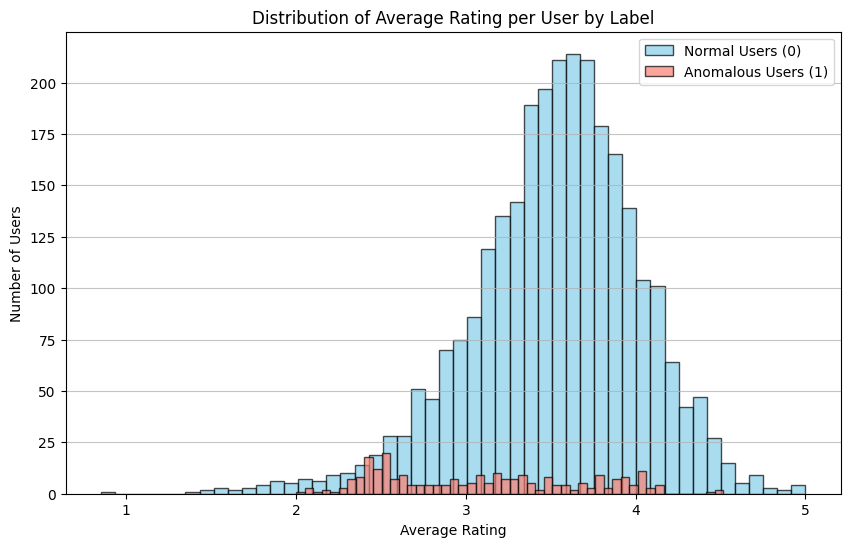

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate average rating per user
user_avg_ratings = XX.groupby("user")["rating"].mean().reset_index()

# Merge with labels using the y array to be safe
df_y = pd.DataFrame(y, columns=["user", "label"])
user_avg_labeled = pd.merge(user_avg_ratings, df_y, on="user")

# Plot the distribution separated by labels
plt.figure(figsize=(10, 6))

# Normal users (label 0)
plt.hist(
    user_avg_labeled[user_avg_labeled["label"] == 0]["rating"],
    bins=50,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="Normal Users (0)",
)

# Anomalous users (label 1)
plt.hist(
    user_avg_labeled[user_avg_labeled["label"] == 1]["rating"],
    bins=50,
    color="salmon",
    edgecolor="black",
    alpha=0.7,
    label="Anomalous Users (1)",
)

plt.title("Distribution of Average Rating per User by Label")
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis="y", alpha=0.75)
plt.show()
# plt.savefig("graphs/Distribution of Average Rating per User by Label.png")

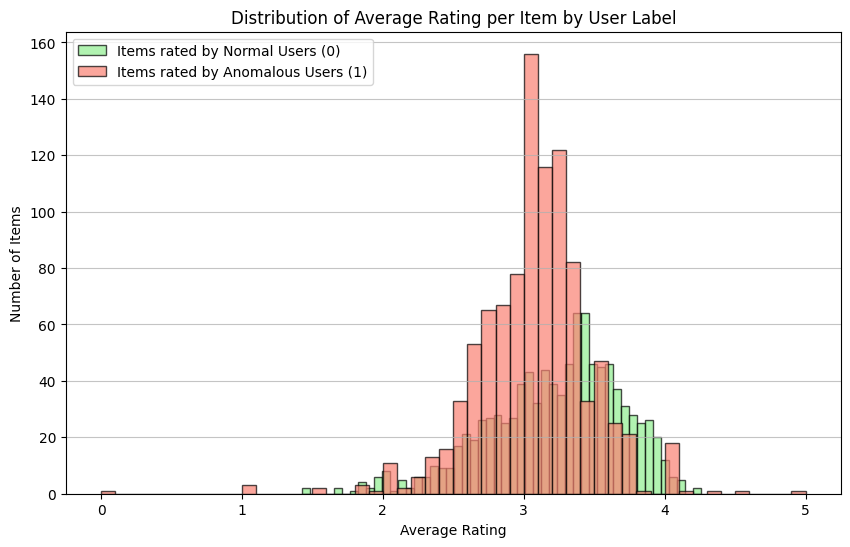

In [6]:
# Calculate average rating per item to compare between normal and anomalous users

# First, merge the labels into the main dataset based on user
XX_labeled = pd.merge(XX, df_y, on="user")

# Calculate average item ratings for normal users
item_avg_normal = XX_labeled[XX_labeled["label"] == 0].groupby("item")["rating"].mean()

# Calculate average item ratings for anomalous users
item_avg_anomalous = (
    XX_labeled[XX_labeled["label"] == 1].groupby("item")["rating"].mean()
)

# Plot the distribution separated by labels
plt.figure(figsize=(10, 6))

# Normal users (label 0)
plt.hist(
    item_avg_normal,
    bins=50,
    color="lightgreen",
    edgecolor="black",
    alpha=0.7,
    label="Items rated by Normal Users (0)",
)

# Anomalous users (label 1)
plt.hist(
    item_avg_anomalous,
    bins=50,
    color="salmon",
    edgecolor="black",
    alpha=0.7,
    label="Items rated by Anomalous Users (1)",
)

plt.title("Distribution of Average Rating per Item by User Label")
plt.xlabel("Average Rating")
plt.ylabel("Number of Items")
plt.legend()
plt.grid(axis="y", alpha=0.75)
plt.show()
# plt.savefig("graphs/Distribution of Average Rating per Item by User Label.png")

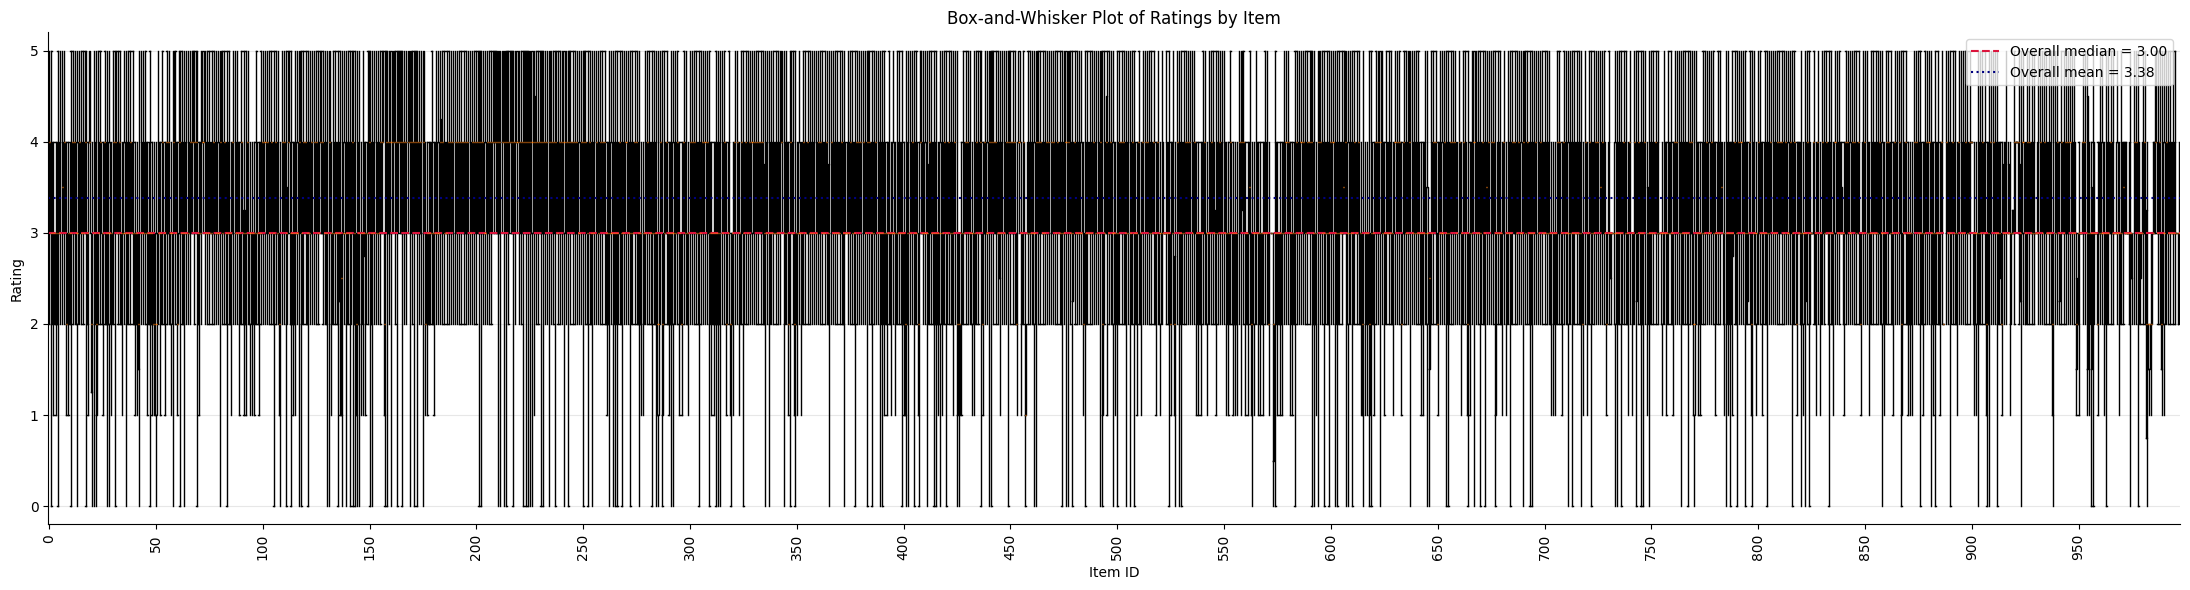

In [7]:
# Box-and-whisker plot of observed ratings for each item
item_ids = sorted(XX["item"].unique())
item_rating_groups = [XX.loc[XX["item"] == item_id, "rating"].values for item_id in item_ids]

plt.figure(figsize=(22, 6))
plt.boxplot(item_rating_groups, showfliers=False)
plt.title("Box-and-Whisker Plot of Ratings by Item")
plt.xlabel("Item ID")
plt.ylabel("Rating")

# Keep x-axis readable
tick_step = 50
tick_positions = np.arange(1, len(item_ids) + 1, tick_step)
tick_labels = [item_ids[i - 1] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
ax = plt.gca()

# Add global reference lines for easier comparison
overall_median = XX["rating"].median()
overall_mean = XX["rating"].mean()
ax.axhline(
    overall_median, color="crimson", linestyle="--", linewidth=1.5,
    label=f"Overall median = {overall_median:.2f}"
)
ax.axhline(
    overall_mean, color="navy", linestyle=":", linewidth=1.5,
    label=f"Overall mean = {overall_mean:.2f}"
)

# Keep rating scale consistent and clean up frame
ax.set_ylim(-0.2, 5.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", frameon=True)

plt.show()

In [8]:
# Frequency table: rows = user type (normal/anomalous), columns = rating value
rating_with_label = XX.merge(df_y, on="user", how="left")

rating_freq_df = pd.crosstab(
    rating_with_label["label"].map({0: "normal", 1: "anomalous"}),
    rating_with_label["rating"],
).reindex(columns=sorted(rating_with_label["rating"].unique()), fill_value=0)

rating_freq_df

rating,0,1,2,3,4,5
label,,,,,,
anomalous,2289,3229,4849,8695,10430,5611
normal,5935,18437,51765,145423,162112,60658


In [9]:
# Check if there are users who rate an item multiple times
duplicates = XX.duplicated(subset=["user", "item"], keep=False)
duplicate_ratings = XX[duplicates].sort_values(by=["user", "item"])

if not duplicate_ratings.empty:
    print(
        f"Found {len(duplicate_ratings)} instances of multiple ratings for the same user and item."
    )
    display(duplicate_ratings.head())
else:
    print(
        "No users rated the same item multiple times. Every user-item interaction is unique."
    )

No users rated the same item multiple times. Every user-item interaction is unique.


--- Sparsity Statistics ---
Minimum ratings by a user: 2
Maximum ratings by a user: 927
Average ratings per user: 156.68
Median ratings per user: 121.0
Overall matrix sparsity: 84.3009%



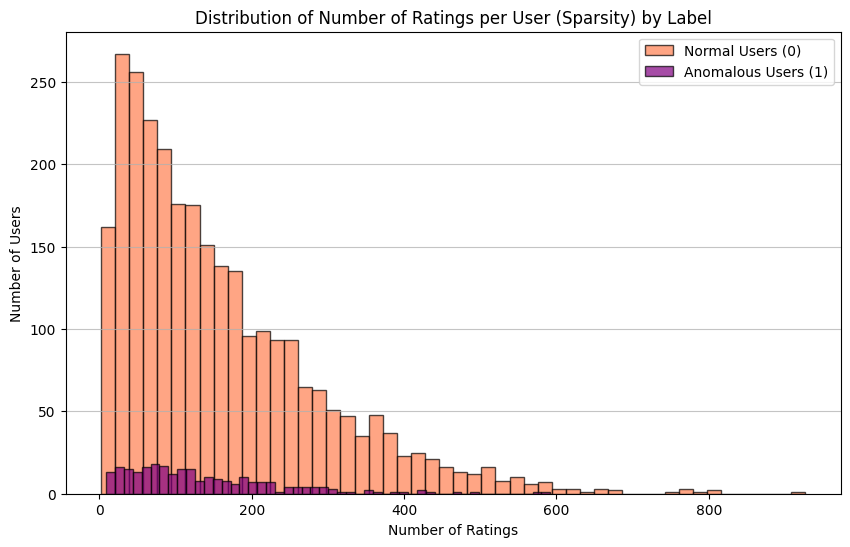

In [10]:
# Calculate the number of ratings each user made to understand sparsity
user_rating_counts = (
    XX_labeled.groupby(["user", "label"]).size().reset_index(name="count")
)

total_possible_ratings = len(XX["user"].unique()) * len(XX["item"].unique())
total_actual_ratings = len(XX)
overall_sparsity = 1.0 - (total_actual_ratings / total_possible_ratings)

# Print out some statistics
print("--- Sparsity Statistics ---")
print(f"Minimum ratings by a user: {user_rating_counts['count'].min()}")
print(f"Maximum ratings by a user: {user_rating_counts['count'].max()}")
print(f"Average ratings per user: {user_rating_counts['count'].mean():.2f}")
print(f"Median ratings per user: {user_rating_counts['count'].median()}")
print(f"Overall matrix sparsity: {overall_sparsity:.4%}\n")

# Plot the distribution of rating counts per user by label
plt.figure(figsize=(10, 6))

# Normal users (label 0)
plt.hist(
    user_rating_counts[user_rating_counts["label"] == 0]["count"],
    bins=50,
    color="coral",
    edgecolor="black",
    alpha=0.7,
    label="Normal Users (0)",
)

# Anomalous users (label 1)
plt.hist(
    user_rating_counts[user_rating_counts["label"] == 1]["count"],
    bins=50,
    color="purple",
    edgecolor="black",
    alpha=0.7,
    label="Anomalous Users (1)",
)

plt.title("Distribution of Number of Ratings per User (Sparsity) by Label")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.legend()
plt.grid(axis="y", alpha=0.75)
plt.show()
# plt.savefig("graphs/Distribution of Number of Ratings per User (Sparsity) by Label.png")

In [11]:
yy.rename(columns={0: "user", 1: "label"}, inplace=True)

In [12]:
yy.head(10)

,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0
5,105,0
6,106,0
7,107,0
8,108,0
9,109,0


In [13]:
X_pred = infer_data["X"]
n_users = len(np.unique(X_pred[:, 0]))

# Generate Random Anomaly Scores
np.random.seed(42)
y_score = np.random.uniform(0, 1, size=n_users)  # random float scores between 0 and 1

print(f"# of predictions:     {len(y_score)}")
print(f"Sample scores:        {y_score[:5]}")

# of predictions:     1625
Sample scores:        [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]


# Example exporting:

```python
# Example with random scores

## Save as submission.npz
np.savez("submission.npz", predictions=y_score)
print("\nsubmission.npz saved successfully!")
```

# Student Response

TLDR:

- This is a dataset of user interactions.
- your job is to find anomalous users based on their current interactions.

### Solution 1: Deep Isolation-Forests

basis:
- I trust you Lord Guansong of the Pang Clan

In [14]:
# pull repo if not yet done
!if exist "deep-iforest/" (echo "Folder exists") else ( git clone https://github.com/xuhongzuo/deep-iforest)

"Folder exists"


Prep data:
- import data
- reformat data to have users as the pivot
- each user will be a 1000-dim vector
    - each dim = 1 item 
    - dim-value ranges from 0 to 6
        - ratings are from 0 to 5, but we offset it by +1 and set 0 as the class for omission
- normalize each vector for training

In [15]:
NUM_ITEMS = 1000

# . convert interactions into a user-item matrix
# Rows = users (ordered by user_id), Cols = items 0..999, Values = rating (0 = no interaction)
df = pd.DataFrame(X, columns=["user", "item", "rating"])
df_by_user_item = df.pivot_table(
    index="user", columns="item", values="rating", fill_value=0
)

# Offset all user-item values by +1: 0..5 -> 1..6
df_by_user_item = df_by_user_item + 1

# Reindex columns to guarantee all 1000 items are present, even if some weren't rated
df_by_user_item = df_by_user_item.reindex(columns=range(NUM_ITEMS), fill_value=0)
df_by_user_item_norm = (
    df_by_user_item / 6.0
)  # Normalize ratings to [0, 1], make a copy for analysis

# user_ids in order, for aligning with labels
user_ids = df_by_user_item.index.to_numpy()
X_matrix = df_by_user_item.to_numpy(dtype=np.float32)  # shape: (n_users, 1000)

# Normalize ratings to [0, 1]
X_matrix = X_matrix / 6.0

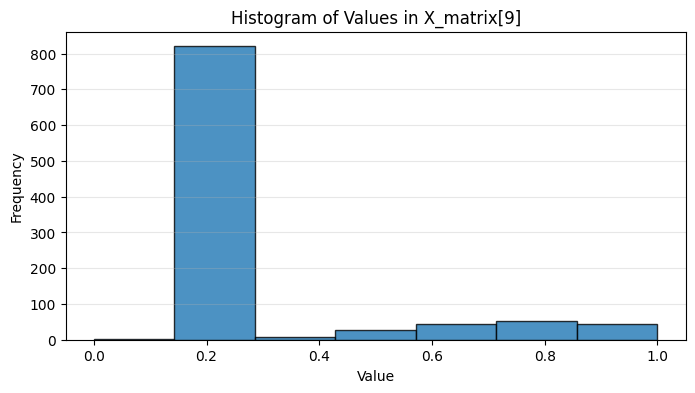

,rating,frequency
0,0.000000,2
1,0.166667,820
2,0.333333,8
3,0.500000,28
4,0.666667,45
5,0.833333,52
6,1.000000,45


In [16]:
vals = X_matrix[9]

plt.figure(figsize=(8, 4))
plt.hist(vals, bins=np.linspace(0, 1, 8), edgecolor="black", alpha=0.8)
plt.title("Histogram of Values in X_matrix[9]")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

vals_df = (
    pd.Series(vals, name="rating")
    .round(6)
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="frequency")
)
display(vals_df)

In [17]:
# . align labels with user_item order
label_df = pd.DataFrame(y, columns=["user", "label"]).set_index("user")
labels = label_df.loc[user_ids, "label"].to_numpy()

# Train only on normal users (label == 0)ll
X_train = X_matrix[labels == 0]
# X_test = X_matrix  # score ALL users at inference

In [18]:
X_matrix.shape, X_train.shape
# X_matrix.shape, X_train.shape, X_test.shape, labels.shape

((3060, 1000), (2800, 1000))

In [19]:
# 80/10/10 split for X_train (train/val/test)
rng = np.random.default_rng(42)

n = X_train.shape[0]
idx = rng.permutation(n)

n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val  # remainder

train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

X_train_split = X_train[train_idx]
X_val = X_train[val_idx]
X_test = X_train[test_idx]

print("Split shapes:")
print("X_train_split:", X_train_split.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Split shapes:
X_train_split: (2240, 1000)
X_val: (280, 1000)
X_test: (280, 1000)


In [24]:
import sys
from pathlib import Path

# Point to cloned repo folder
deep_iforest_path = Path("deep-iforest").resolve()
if str(deep_iforest_path) not in sys.path:
    sys.path.insert(0, str(deep_iforest_path))

# Import DIF class
from algorithms.dif import DIF

# Example usage
model = DIF(n_ensemble=80, n_estimators=9)
model.fit(X_train)
score = model.decision_function(X_test)

network additional parameters: {'n_hidden': [500, 100], 'n_emb': 20, 'skip_connection': None, 'dropout': None, 'activation': 'tanh', 'be_size': 80}


In [25]:
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
import numpy as np

# Score all labeled users (recommended for valid AUC/F1)
all_scores = model.decision_function(X_matrix)
y_true = labels.astype(int)

auc = roc_auc_score(y_true, all_scores)

# Choose threshold that maximizes F1 on labeled data
precision, recall, thresholds = precision_recall_curve(y_true, all_scores)
f1_per_threshold = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-12)
best_idx = np.argmax(f1_per_threshold)
best_threshold = thresholds[best_idx]

y_pred = (all_scores >= best_threshold).astype(int)
f1 = f1_score(y_true, y_pred)

print(f"AUC (all labeled users): {auc:.6f}")
print(f"Best threshold: {best_threshold:.6f}")
print(f"F1 (at best threshold): {f1:.6f}")

# Optional: check existing `score` variable from X_test split
if "score" in globals():
    if len(score) == len(labels):
        auc_score_var = roc_auc_score(y_true, score)
        p2, r2, t2 = precision_recall_curve(y_true, score)
        f1_t2 = 2 * p2[1:] * r2[1:] / (p2[1:] + r2[1:] + 1e-12)
        i2 = np.argmax(f1_t2)
        y_pred2 = (score >= t2[i2]).astype(int)
        f1_score_var = f1_score(y_true, y_pred2)
        print(f"AUC (`score`): {auc_score_var:.6f}")
        print(f"F1 (`score`, best threshold): {f1_score_var:.6f}")
    else:
        print("Note: `score` length does not match `labels`; skipped direct eval on `score`.")

AUC (all labeled users): 0.627891
Best threshold: 0.332681
F1 (at best threshold): 0.238245
Note: `score` length does not match `labels`; skipped direct eval on `score`.


In [26]:
import zipfile
import pandas as pd
import numpy as np

# Load infer data
X_pred = infer_data["X"]

# Process inference data the same way as training data
df_infer = pd.DataFrame(X_pred, columns=["user", "item", "rating"])
df_infer_by_user_item = df_infer.pivot_table(
    index="user", columns="item", values="rating", fill_value=0
)

# Offset all user-item values by +1: 0..5 -> 1..6
df_infer_by_user_item = df_infer_by_user_item + 1

# Reindex columns to guarantee all 1000 items are present
df_infer_by_user_item = df_infer_by_user_item.reindex(columns=range(NUM_ITEMS), fill_value=0)

X_matrix_infer = df_infer_by_user_item.to_numpy(dtype=np.float32)

# Normalize ratings to [0, 1]
X_matrix_infer = X_matrix_infer / 6.0

# Generate predictions using the trained DIF model
y_score = model.decision_function(X_matrix_infer)

# Save as .npz
np.savez("submission.npz", predictions=y_score)

# Zip the file
with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write("submission.npz")
    
print("Prediction and zipping completed successfully! Saved to submission.zip")

Prediction and zipping completed successfully! Saved to submission.zip


In [27]:
print("First 10 anomaly scores:", y_score[:10])
print("Mean score:", y_score.mean())

First 10 anomaly scores: [0.31377119 0.32295099 0.33450054 0.32212231 0.33236774 0.31697216
 0.32733235 0.34223786 0.32405211 0.32183743]
Mean score: 0.32808276713742074
